# Explore anomaly scores

In [2]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [4]:
mse_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]
mse_rank_cols = [
    f"rank_{col}" for col in mse_cols
]
mse_rel_cols = [
    f"{col}_rel" for col in mse_cols
]
mse_rank_rel_cols = [
    f"rank_{col}_rel" for col in mse_cols
]
# ----------------------------------------------
mse_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

chi_sq_family = [
    f'{col}_rel' for col in mse_family
]

# Custom functions

## Scores arr to df

In [5]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        print(f"Loading score: {score_name}")

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'

    return scores_df


## Residuals

In [6]:
def abs_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff

## Score name map

In [7]:
def map_score_name(score):
    """Maps score code names to more readable names."""
    if score == 'mse':
        return 'SE'
    elif score == 'mse_filter_250':
        return 'Filtered SE'
    elif score == 'mse_97':
        return 'Trimmed SE'
    elif score == 'mse_filter_250_97':
        return 'Filtered + Trimmed SE'
    
    elif score == 'mse_rel':
        return 'RSE'
    elif score == 'mse_filter_250_rel':
        return 'Filtered RSE'
    elif score == 'mse_97_rel':
        return 'Trimmed RSE'
    elif score == 'mse_filter_250_97_rel':
        return 'Filtered + Trimmed RSE'
    else:
        return score

## Score dist

In [8]:
def plot_hist_scores(
    df,
    score_family,
    x_label,
    bins=100,
    y_lim=(None, None)
):
    """
    Generates a 2x2 grid of histograms for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(20, 9)
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        _ = axs[i].hist(
            df[score], 
            bins=bins,
            color='tab:blue', edgecolor='black',
            linewidth=0.5
        )
        axs[i].set_yscale('log')
        axs[i].set_ylim(y_lim)
        # Formatting
        axs[i].minorticks_on()

        score_mapped = map_score_name(score)
        axs[i].text(
            0.5, 0.95,
            score_mapped,
            horizontalalignment="center", verticalalignment="center",
            transform=axs[i].transAxes,
            fontsize=12
        )

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)

    return fig, axs

## score Vs z \& S/N

In [9]:
def plot_hist_score_z_snr(
    df,
    score_family,
    x_col, x_label,
    gridsize=100,
    figsize=(20, 9)
):
    """
    Generates a 2x2 grid of hexbin plots for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=figsize
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        hb = axs[i].hexbin(
            df[x_col], 
            df[score], 
            gridsize=gridsize, 
            cmap='viridis',
            mincnt=1, 
            bins='log'
        )
        
        # Formatting
        axs[i].minorticks_on()
        score_mapped = map_score_name(score)            
        axs[i].set_title(score_mapped, fontsize=12)

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)
        
        # Add colorbar
        cb = fig.colorbar(hb, ax=axs[i])
        if i == 1 or i == 3:
            cb.set_label('Count')

    return fig, axs

# Config

## Directories

In [10]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = "bin_02"
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

## Data

In [11]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


## Model

In [12]:
ae_winner = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner_0021",
)

In [13]:
ae_winner.hyperparameters

{'validation_split': 0.2,
 'learning_rate': 0.001,
 'batch_size': 256,
 'epochs': 120,
 'output_activation': 'linear',
 'early_stop_patience': 10,
 'verbose_early_stop': 0,
 'learning_rate_patience': 5,
 'verbose_learning_rate': 0,
 'workers': 2,
 'use_multiprocessing': False,
 'reconstruction_weight': 3776,
 'alpha': 0,
 'lambda': 12.881673594609445}

## Scores

In [14]:
# # ```python

# score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

# bin_idx_to_specobjid = np.load(
#     f"{spectra_dir}/"
#     f"{bin_id}/{bin_id}_index_specobjid.npy"
# )

# scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
# scores_df.to_csv(
#     f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
#     index=True
# )
# # ```

In [15]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

In [16]:
score_rank_df[['rank_mse', 'mse']].sort_values(by='mse', ascending=False).head(5)

,rank_mse,mse
specobjid,,
1645099794210777088,1.0,156.687047
1974866976299837440,2.0,110.599323
407583221518198784,3.0,103.278770
407585145663547392,4.0,77.283062
378398609504233472,5.0,73.287946


In [17]:
score_rank_df[['rank_mse', 'mse']].sort_values(by='mse', ascending=True).head(5)

,rank_mse,mse
specobjid,,
3146956011999356928,181850.0,2.278029
1575147766785533952,181849.0,2.315862
1051614747075569664,181848.0,2.316965
2000776700849317888,181847.0,2.317066
2344153074320304128,181846.0,2.317402


In [18]:
spec_id = 1645099794210777088
score_rank_df.loc[spec_id, mse_cols + mse_rel_cols]

mse                      156.687047
mse_filter_250            97.455154
mse_97                     6.592117
mse_filter_250_97          5.105078
mse_rel                   75.260937
mse_filter_250_rel        15.564189
mse_97_rel                 6.013027
mse_filter_250_97_rel      4.957569
Name: 1645099794210777088, dtype: float64

In [19]:
spec_id = 1645099794210777088
score_rank_df.loc[spec_id, mse_rank_cols + mse_rank_rel_cols]

rank_mse                        1.0
rank_mse_filter_250             3.0
rank_mse_97                    25.0
rank_mse_filter_250_97        101.0
rank_mse_rel                    1.0
rank_mse_filter_250_rel         1.0
rank_mse_97_rel                52.0
rank_mse_filter_250_97_rel    165.0
Name: 1645099794210777088, dtype: float64

# Good and bad rec

## Data

In [20]:
rec_good_bad_dict = {
    'good': 3146956011999356928,
    'bad': 1645099794210777088
}

bad_id = rec_good_bad_dict["bad"]
idx_bad = specobjid_to_idx(bad_id, idx_id_spec)
bad_spec = spectra[idx_bad]
rec_bad_spec = ae_winner.reconstruct(bad_spec)[0]
residual_bad = abs_residual(bad_spec, rec_bad_spec)
# -----------------------------------------
good_id = rec_good_bad_dict["good"]
idx_good = specobjid_to_idx(good_id, idx_id_spec)
good_spec = spectra[idx_good]
rec_good_spec = ae_winner.reconstruct(good_spec)[0]
residual_good = abs_residual(good_spec, rec_good_spec)

## Figure

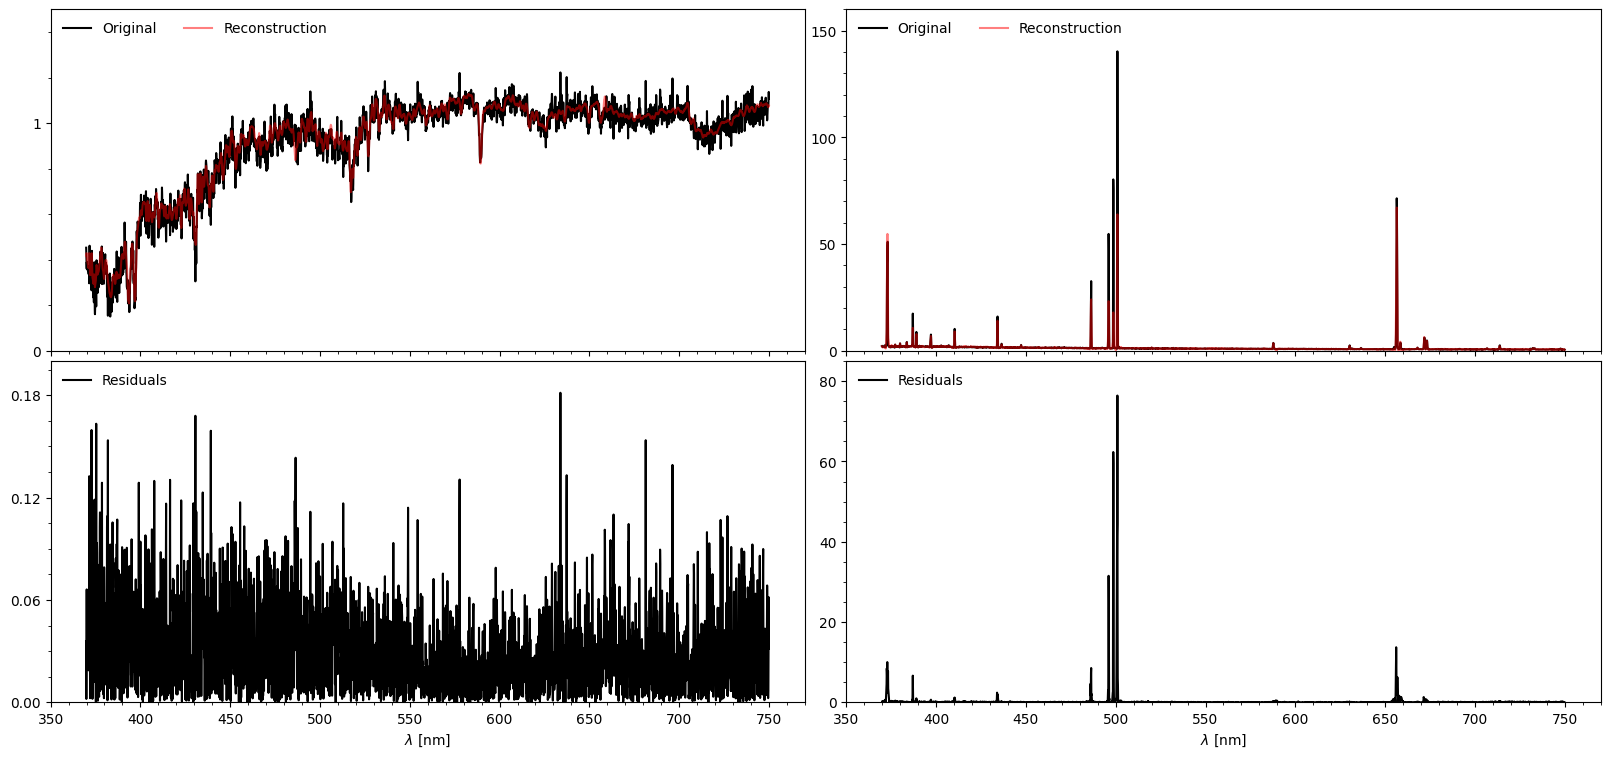

In [21]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)
alpha = 0.5
# ----------------------------------------------------
# Normal
axs[0, 0].plot(
    wave_nm, good_spec,
    color="black", label="Original"
)

axs[0, 0].plot(
    wave_nm, rec_good_spec,
    alpha=alpha,
    color="red", label="Reconstruction"
)

flux_ticks = [0, 1]
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(0, 1.5)

# ----------------------------------------------------
# Anomaly
axs[0, 1].plot(
    wave_nm, bad_spec,
    color="black", label="Original"
)
axs[0, 1].plot(
    wave_nm, rec_bad_spec,
    color="red", alpha=alpha, label="Reconstruction"
)

flux_ticks = [0, 50, 100, 150]
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(0, 160)
# ----------------------------------------------------
# Residulas
# Normal
axs[1, 0].plot(
    wave_nm, residual_good,
    color="black", label="Residuals"
)

res_ticks = [0, 0.06, 0.12, 0.18]
axs[1, 0].set_yticks(res_ticks)
axs[1, 0].set_ylim(0, 0.2)

# Anomaly
axs[1, 1].plot(
    wave_nm, residual_bad,
    color="black", label="Residuals"
)

res_ticks = [0, 20, 40, 60, 80]
axs[1, 1].set_yticks(res_ticks)
axs[1, 1].set_ylim(0, 85)

# ----------------------------------------------------
# labels
axs[0, 0].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[0, 1].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[1, 0].legend(loc='upper left', frameon=False)
axs[1, 1].legend(loc='upper left', frameon=False)

# ----------------------------------------------------

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)
# # wave_ticks = [370]
wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten(): ax.minorticks_on()
# remove 0 flux label

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.055
)
# --------------------------
# create dir if not exist
save_to = f"{ch_4_dir}/{bin_id}"

os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/good_poor_reconstruction_{bin_id}.pdf",
    bbox_inches='tight'
)

# MSE illustrations

## MSE Data 

In [22]:
# #need to find equivalents for this score
# mse_strong_artifact = {
#     'strong':734111514142730240,
#     'artifact': 378399434137954304
# }

# strong_id = mse_strong_artifact["strong"]
# idx_strong = specobjid_to_idx(strong_id, idx_id_spec)
# strong_spec = spectra[idx_strong]
# rec_strong_spec = ae_winner.reconstruct(strong_spec)[0]
# residual_strong = abs_residual(strong_spec, rec_strong_spec)
# # -----------------------------------------
# artifact_id = mse_strong_artifact["artifact"]
# idx_artifact = specobjid_to_idx(artifact_id, idx_id_spec)
# artifact_spec = spectra[idx_artifact]
# rec_artifact_spec = ae_winner.reconstruct(artifact_spec)[0]
# residual_artifact = abs_residual(artifact_spec, rec_artifact_spec)
# # ----------------------------------------------------
# # MSE anomaly score
# mse_strong = score_df.loc[strong_id, 'mse']
# mse_artifact = score_df.loc[artifact_id, 'mse']
# mse_strong, mse_artifact

## MSE Figure

In [23]:
# fig, axs = plt.subplots(
#     2, 2,
#     sharex=True,
#     figsize=(20, 9)
# )
# alpha = 0.5
# # ----------------------------------------------------
# # Strong
# axs[0, 0].plot(
#     wave_nm, strong_spec,
#     color="black", label="Original"
# )

# axs[0, 0].plot(
#     wave_nm, rec_strong_spec,
#     alpha=alpha,
#     color="red", label="Reconstruction"
# )

# flux_ticks = [0, 25, 50, 75, 100]
# axs[0, 0].set_yticks(flux_ticks)
# axs[0, 0].set_ylim(0, 110)

# # ----------------------------------------------------
# # Artifact
# axs[0, 1].plot(
#     wave_nm, artifact_spec,
#     color="black", label="Original"
# )
# axs[0, 1].plot(
#     wave_nm, rec_artifact_spec,
#     color="red", alpha=alpha, label="Reconstruction"
# )

# flux_ticks = [0, 9, 18, 27, 36]
# axs[0, 1].set_yticks(flux_ticks)
# axs[0, 1].set_ylim(0, 40)
# # ----------------------------------------------------
# # Residulas
# # Strong
# axs[1, 0].plot(
#     wave_nm, residual_strong,
#     color="black", label="Residuals"
# )
# res_ticks = [0, 9, 18, 27, 36]
# axs[1, 0].set_yticks(res_ticks)
# axs[1, 0].set_ylim(0, 38)

# axs[1, 0].text(
#     0.95, 0.95,
#     f"Squared error: {mse_strong:.2f}",
#     horizontalalignment="right", verticalalignment="center",
#     transform=axs[1, 0].transAxes,
#     fontsize=12
# )

# # Artifact
# axs[1, 1].plot(
#     wave_nm, residual_artifact,
#     color="black", label="Residuals"
# )

# res_ticks = [0, 9, 18, 27, 36]
# axs[1, 1].set_yticks(res_ticks)
# axs[1, 1].set_ylim(0, 38)

# axs[1, 1].text(
#     0.95, 0.95,
#     f"Squared error: {mse_artifact:.2f}",
#     horizontalalignment="right", verticalalignment="center",
#     transform=axs[1, 1].transAxes,
#     fontsize=12
# )
# # ----------------------------------------------------
# # labels
# axs[0, 0].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# axs[0, 1].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# axs[1, 0].legend(loc='upper left', frameon=False)
# axs[1, 1].legend(loc='upper left', frameon=False)

# # ----------------------------------------------------

# # wavelengt setup
# axs[1, 0].set_xlim(350, 770)
# axs[1, 1].set_xlim(350, 770)
# # # wave_ticks = [370]
# wave_ticks = list(np.arange(350, 751, 50))
# axs[1, 0].set_xticks(wave_ticks)
# axs[1, 1].set_xticks(wave_ticks)
# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()
# # remove 0 flux label

# axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
# axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# # adjust vertical space
# plt.subplots_adjust(
#     hspace=0.03, 
#     wspace=0.055
# )

# fig.savefig(
#     f"{ch_4_dir}/mse_residual_strong_artifact.pdf",
#     bbox_inches='tight'
# )

## Filtered MSE Data

In [24]:
# broad_specobjid = 1924292192684238848
# idx_broad = specobjid_to_idx(broad_specobjid, idx_id_spec)
# spec_broad = spectra[idx_broad]
# spec_broad_rec = ae_winner.reconstruct(spec_broad).reshape(-1)
# residual_broad = abs_residual(spec_broad, spec_broad_rec)
# # -------------------------------------------------------
# # score and rank
# mse_broad = score_df.loc[broad_specobjid, 'mse']
# mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse']
# filtered_250_mse_broad = score_df.loc[broad_specobjid, 'mse_filter_250']
# filtered_250_mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse_filter_250']
# filtered_300_mse_broad = score_df.loc[broad_specobjid, 'mse_filter_300']
# filtered_300_mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse_filter_300']

In [25]:
# blue_specobjid = 3240361172402202624
# idx_blue = specobjid_to_idx(blue_specobjid, idx_id_spec)
# spec_blue = spectra[idx_blue]
# spec_blue_rec = ae_winner.reconstruct(spec_blue).reshape(-1)
# residual_blue = abs_residual(spec_blue, spec_blue_rec)
# # -------------------------------------------------------
# # score and rank
# mse_blue = score_df.loc[blue_specobjid, 'mse']
# mse_blue_rank = score_rank_df.loc[blue_specobjid, 'rank_mse']
# filtered_250_mse_blue = score_df.loc[blue_specobjid, 'mse_filter_250']
# filtered_250_mse_blue_rank = score_rank_df.loc[blue_specobjid, 'rank_mse_filter_250']
# filtered_300_mse_blue = score_df.loc[blue_specobjid, 'mse_filter_300']
# filtered_300_mse_blue_rank = score_rank_df.loc[blue_specobjid, 'rank_mse_filter_300']

In [26]:
# emission_lines = list(GALAXY_LINES.keys())

# velocity_fil_fn = VelocityFilter(
#     wave=wave, velocity_filter=250,
#     lines=emission_lines
# )

# vel_mask = velocity_fil_fn.get_velocity_filter_mask()

## Filtered MSE figure

In [27]:
# fig, axs = plt.subplots(
#     2, 2,
#     sharex=True,
#     figsize=(20, 9)
# )
# # ----------------------------------------------------
# # broad
# axs[0, 0].plot(wave_nm, spec_broad, color='black', alpha=1, label='Original')
# axs[0, 0].plot(wave_nm, spec_broad_rec, color='red', alpha=0.5, label='Reconstruction')

# flux_ticks = [0, 5, 10, 15]
# axs[0, 0].set_yticks(flux_ticks)
# axs[0, 0].set_ylim(0, 16)
# # ----------------------------------------------------
# # residual
# axs[1, 0].plot(wave_nm, residual_broad, color='black')
# res_ticks = [0, 1, 2, 3]
# axs[1, 0].set_yticks(res_ticks)
# axs[1, 0].set_ylim(0, 3.1)
# # squared error  and rank
# axs[1, 0].text(
#     0.375, 0.92,
#     f"Filtered SE: {filtered_250_mse_broad:.2f} "
#     f"(Rank: {filtered_250_mse_broad_rank:.0f})\n"
#     f"SE: {mse_broad:.2f} "
#     f"(Rank: {mse_broad_rank:.0f})",
#     horizontalalignment="left", verticalalignment="center",
#     transform=axs[1, 0].transAxes,
#     fontsize=10
# )
# # ----------------------------------------------------
# # blue
# axs[0, 1].plot(wave_nm, spec_blue, color='black', alpha=1, label='Original')
# axs[0, 1].plot(wave_nm, spec_blue_rec, color='red', alpha=0.5, label='Reconstruction')

# flux_ticks = [0, 2, 4]
# axs[0, 1].set_yticks(flux_ticks)
# axs[0, 1].set_ylim(0, 5)
# # ----------------------------------------------------
# # residual
# axs[1, 1].plot(wave_nm, residual_blue, color='black')

# res_ticks = [0, 0.3, 0.6, 0.9]
# axs[1, 1].set_yticks(res_ticks)
# axs[1, 1].set_ylim(0, 1)
# # squared error  and rank
# axs[1, 1].text(
#     0.375, 0.92,
#     f"Filtered SE: {filtered_250_mse_blue:.2f} "
#     f"(Rank: {filtered_250_mse_blue_rank:.0f})\n"
#     f"SE: {mse_blue:.2f} "
#     f"(Rank: {mse_blue_rank:.0f})",
#     horizontalalignment="left", verticalalignment="center",
#     transform=axs[1, 1].transAxes,
#     fontsize=10
# )
# # ----------------------------------------------------
# # shaded regions
    
# axs[1, 0].fill_between(
#     wave_nm, 
#     0, 1,              # Fill from bottom (0) to top (1) of the axis
#     where=~vel_mask,    # Only where your mask is True
#     color='gray',      # Color of the shade
#     alpha=0.5,         # Transparency
#     transform=axs[1, 0].get_xaxis_transform(), # Key: maps y to axis fractions
#     label='Emission Lines'
# )
# axs[1, 1].fill_between(
#     wave_nm, 
#     0, 1,              # Fill from bottom (0) to top (1) of the axis
#     where=~vel_mask,    # Only where your mask is True
#     color='gray',      # Color of the shade
#     alpha=0.5,         # Transparency
#     transform=axs[1, 1].get_xaxis_transform(), # Key: maps y to axis fractions
#     label='Emission Lines'
# )

# # ----------------------------------------------------
# # labels
# axs[0, 0].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# axs[0, 1].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# # # leggends
# axs[1, 0].legend(loc='upper right', frameon=False, fontsize=10)
# axs[1, 1].legend(loc='upper right', frameon=False, fontsize=10)
# # for ax in axs.flatten():
# #     ax.legend(loc='upper right', frameon=False, fontsize=10)
# # ---------------------------------------------------- 
# # wavelengt setup
# axs[1, 1].set_xlim(350, 770)
# axs[0, 1].set_xlim(350, 770)
# # # wave_ticks = [370]
# wave_ticks = list(np.arange(350, 751, 50))
# axs[1, 1].set_xticks(wave_ticks)
# axs[0, 1].set_xticks(wave_ticks)
# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

# axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
# # adjust vertical space
# plt.subplots_adjust(hspace=0.05, wspace=0.05)
# # ---------------------------------------------------- 
# fig.savefig(
#     f"{ch_4_dir}/filtered_mse_residual_broad.pdf",
#     bbox_inches='tight'
# )

## Trimmed MSE data

In [28]:
# score_rank_df.loc[broad_specobjid, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']]

In [29]:
# score_rank_df.loc[strong_id, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']]

In [30]:
# score_rank_df.loc[artifact_id, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']

In [31]:
# line_bumpy_id = 1530151624956209152
# idx_line_bumpy = specobjid_to_idx(line_bumpy_id, idx_id_spec)
# spec_line_bumpy = spectra[idx_line_bumpy]
# spec_line_bumpy_rec = ae_winner.reconstruct(spec_line_bumpy).reshape(-1)
# residual_line_bumpy = abs_residual(spec_line_bumpy, spec_line_bumpy_rec)
# threshold_line_bumpy = np.nanpercentile(residual_line_bumpy, 97)
# # -------------------------------------------------------
# # score and rank
# mse_line_bumpy = score_df.loc[line_bumpy_id, 'mse']
# mse_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse']
# filtered_250_mse_line_bumpy = score_df.loc[line_bumpy_id, 'mse_filter_250']
# filtered_250_mse_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse_filter_250']
# mse_97_line_bumpy = score_df.loc[line_bumpy_id, 'mse_97']
# mse_97_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse_97']

In [32]:
# mse_line_bumpy, mse_line_bumpy_rank, \
# filtered_250_mse_line_bumpy, filtered_250_mse_line_bumpy_rank, \
# mse_97_line_bumpy, mse_97_line_bumpy_rank

In [33]:
# star_id = 2486065949363431424
# idx_star = specobjid_to_idx(star_id, idx_id_spec)
# spec_star = spectra[idx_star]
# spec_star_rec = ae_winner.reconstruct(spec_star).reshape(-1)
# residual_star = abs_residual(spec_star, spec_star_rec)
# threshold_star = np.nanpercentile(residual_star, 97)
# # -------------------------------------------------------
# # score and rank
# mse_star = score_df.loc[star_id, 'mse']
# mse_star_rank = score_rank_df.loc[star_id, 'rank_mse']
# filtered_250_mse_star = score_df.loc[star_id, 'mse_filter_250']
# filtered_250_mse_star_rank = score_rank_df.loc[star_id, 'rank_mse_filter_250']
# mse_97_star = score_df.loc[star_id, 'mse_97']
# mse_97_star_rank = score_rank_df.loc[star_id, 'rank_mse_97']

## Trimmed MSE figure

In [34]:
# fig, axs = plt.subplots(
#     2, 2,
#     sharex=True,
#     figsize=(20, 9)
# )
# alpha = 0.5
# # ----------------------------------------------------
# # Line bumpy
# axs[0, 0].plot(
#     wave_nm, spec_line_bumpy,
#     color="black", label="Original"
# )

# axs[0, 0].plot(
#     wave_nm, spec_line_bumpy_rec,
#     alpha=alpha,
#     color="red", label="Reconstruction"
# )

# flux_ticks = [0, 3, 6, 9]
# axs[0, 0].set_yticks(flux_ticks)
# axs[0, 0].set_ylim(0, 9.5)

# # ----------------------------------------------------
# # star
# axs[0, 1].plot(
#     wave_nm, spec_star,
#     color="black", label="Original"
# )
# axs[0, 1].plot(
#     wave_nm, spec_star_rec,
#     color="red", alpha=alpha, label="Reconstruction"
# )

# flux_ticks = [0, 0.5, 1, 1.5]
# axs[0, 1].set_yticks(flux_ticks)
# axs[0, 1].set_ylim(0, 1.6)
# # ----------------------------------------------------
# # Residulas
# # line bumpy
# axs[1, 0].plot(
#     wave_nm, residual_line_bumpy,
#     color="black", label="Residuals"
# )
# res_ticks = [0, 1, 2, 3]
# axs[1, 0].set_yticks(res_ticks)
# axs[1, 0].set_ylim(0, 3.1)

# # star
# axs[1, 1].plot(
#     wave_nm, residual_star,
#     color="black", label="Residuals"
# )

# res_ticks = [0, 0.1, 0.2, 0.3]
# axs[1, 1].set_yticks(res_ticks)
# axs[1, 1].set_ylim(0, 0.33)

# # ----------------------------------------------------
# # Sqared error  and rank
# axs[1, 0].text(
#     0.02, 0.91,
#     f"Trimed SE: {mse_97_line_bumpy:.2f} "
#     f"(Rank: {mse_97_line_bumpy_rank:.0f})\n"
#     f"Filtered SE: {filtered_250_mse_line_bumpy:.2f} "
#     f"(Rank: {filtered_250_mse_line_bumpy_rank:.0f})\n"
#     f"SE: {mse_line_bumpy:.2f} "
#     f"(Rank: {mse_line_bumpy_rank:.0f})",
#     horizontalalignment="left", verticalalignment="center",
#     transform=axs[1,0].transAxes,
#     fontsize=10
# )

# axs[1, 1].text(
#     0.02, 0.91,
#     f"Trimed SE: {mse_97_star:.2f} "
#     f"(Rank: {mse_97_star_rank:.0f})\n"
#     f"Filtered SE: {filtered_250_mse_star:.2f} "
#     f"(Rank: {filtered_250_mse_star_rank:.0f})\n"
#     f"SE: {mse_star:.2f} "
#     f"(Rank: {mse_star_rank:.0f})",
#     horizontalalignment="left", verticalalignment="center",
#     transform=axs[1,1].transAxes,
#     fontsize=10
# )
# # ----------------------------------------------------
# # threshold lines
# axs[1, 0].axhline(
#     y=threshold_line_bumpy, 
#     color='blue', 
#     linestyle='--', 
#     linewidth=2,
#     label=f'Trim 3%: {threshold_line_bumpy:.2f}'
# )
# axs[1, 1].axhline(
#     y=threshold_star, 
#     color='blue', 
#     linestyle='--', 
#     linewidth=2,
#     label=f'Trim 3%: {threshold_star:.2f}'
# )
# # ----------------------------------------------------
# # labels
# axs[0, 0].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# axs[0, 1].legend(
#     loc='upper left',
#     frameon=False,
#     # fontsize=10,
#     ncol=2
# )
# axs[1, 0].legend(loc='upper right', frameon=False)
# axs[1, 1].legend(loc='upper right', frameon=False)
# # ----------------------------------------------------

# # wavelengt setup
# axs[1, 0].set_xlim(350, 770)
# axs[1, 1].set_xlim(350, 770)
# # # wave_ticks = [370]
# wave_ticks = list(np.arange(350, 751, 50))
# axs[1, 0].set_xticks(wave_ticks)
# axs[1, 1].set_xticks(wave_ticks)
# # set minor ticks on
# for ax in axs.flatten(): ax.minorticks_on()

# axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
# axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# # adjust vertical space
# plt.subplots_adjust(
#     hspace=0.03,
#     wspace=0.06
# )

# fig.savefig(
#     f"{ch_4_dir}/mse_97_residual_line_bumpy_star.pdf",
#     bbox_inches='tight'
# )

# Ranks of Specs in figures

In [35]:
# mse_strong_artifact = {
#     'strong':734111514142730240,
#     'artifact': 378399434137954304
# }
# strong_id = mse_strong_artifact["strong"]
# artifact_id = mse_strong_artifact["artifact"]

# filtered_broad_blue = {
#     'broad':1924292192684238848,
#     'blue': 3240361172402202624
# }
# broad_id = filtered_broad_blue["broad"]
# blue_id = filtered_broad_blue["blue"]

# trimmed_bumpy_star = {
#     'bumpy':1530151624956209152,
#     'star': 2486065949363431424
# }

# bumpy_id = trimmed_bumpy_star["bumpy"]
# star_id = trimmed_bumpy_star["star"]

In [36]:
# score_rank_df.loc[
#     [strong_id, artifact_id, broad_id, blue_id, bumpy_id, star_id],
#     ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97', 'rank_mse_filter_250_97']
# ]

In [38]:
# score_rank_df.loc[
#     [strong_id, artifact_id, broad_id, blue_id, bumpy_id, star_id],
#     ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
# ]

# Histograms Scores

## Data prep

In [39]:
score_cols = mse_cols + mse_rel_cols
rank_cols = mse_rank_cols + mse_rank_rel_cols

merged_df = score_rank_df[score_cols + rank_cols].join(
    final_meta_df[['z', 'snMedian']],
    how='inner'
).copy()

merged_df[score_cols] = merged_df[
    score_cols
] / merged_df[score_cols].max()

## Score descriptive stats

In [40]:
merged_df[score_cols].describe(
    percentiles=np.linspace(0.1, 0.9, 9)
)

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
count,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000
mean,0.022975,0.031282,0.305886,0.309258,0.052356,0.246755,0.348719,0.350048
std,0.007539,0.008876,0.042666,0.041668,0.008832,0.036013,0.041426,0.041141
min,0.014539,0.020108,0.207028,0.209273,0.034789,0.164885,0.240953,0.238662
10%,0.018351,0.025470,0.256584,0.260629,0.043754,0.206646,0.299301,0.300651
20%,0.019464,0.026939,0.270102,0.274060,0.046097,0.217754,0.313227,0.314655
30%,0.020362,0.028131,0.281187,0.285052,0.047994,0.226691,0.324711,0.326072
40%,0.021185,0.029215,0.290999,0.294915,0.049698,0.234776,0.335207,0.336670
50%,0.022013,0.030289,0.300700,0.304505,0.051372,0.242628,0.345451,0.346952
60%,0.022924,0.031447,0.311023,0.314582,0.053111,0.250882,0.355627,0.357086


## Top 1% score thresholds

In [41]:
top_1_thresholds = merged_df[score_cols].quantile(0.99)
print("Score thresholds for the Top 1% of anomalies:")
print("-" * 40)
print(top_1_thresholds)

Score thresholds for the Top 1% of anomalies:
----------------------------------------
mse                      0.039652
mse_filter_250           0.048930
mse_97                   0.429481
mse_filter_250_97        0.427977
mse_rel                  0.076305
mse_filter_250_rel       0.352929
mse_97_rel               0.464282
mse_filter_250_97_rel    0.463611
Name: 0.99, dtype: float64


## MSE family dist

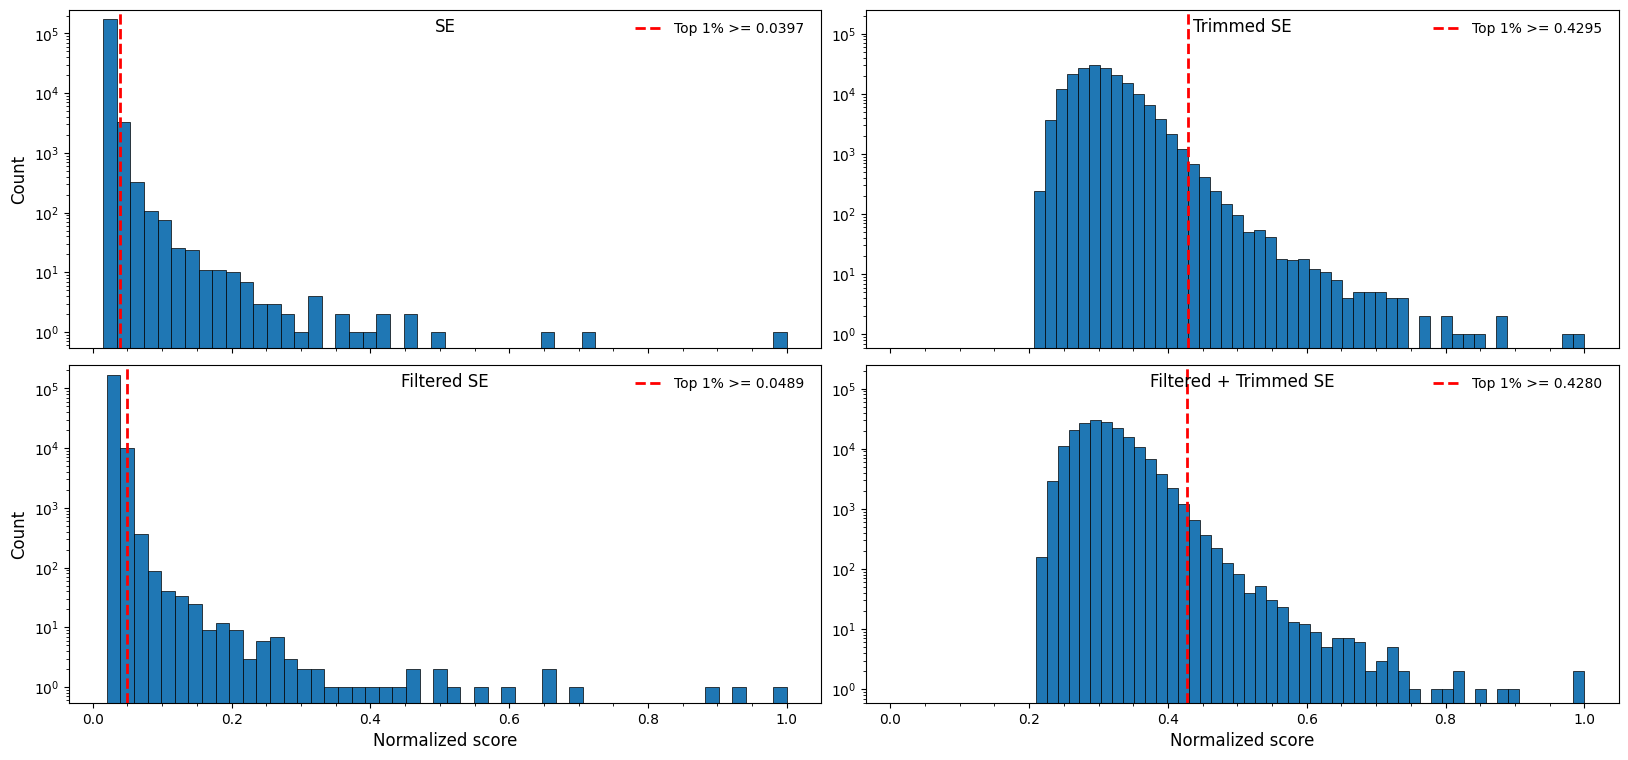

In [42]:
fig, axs = plot_hist_scores(
    merged_df,
    mse_family,
    x_label='Normalized score',
    bins=50,
    y_lim=(None, 0.25e6)
)

for i, score in enumerate(mse_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Count', fontsize=12)
axs[2].set_ylabel('Count', fontsize=12)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)
# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hist_se_scores_{bin_id}.pdf",
    bbox_inches='tight'
)

## Chi sq family dist

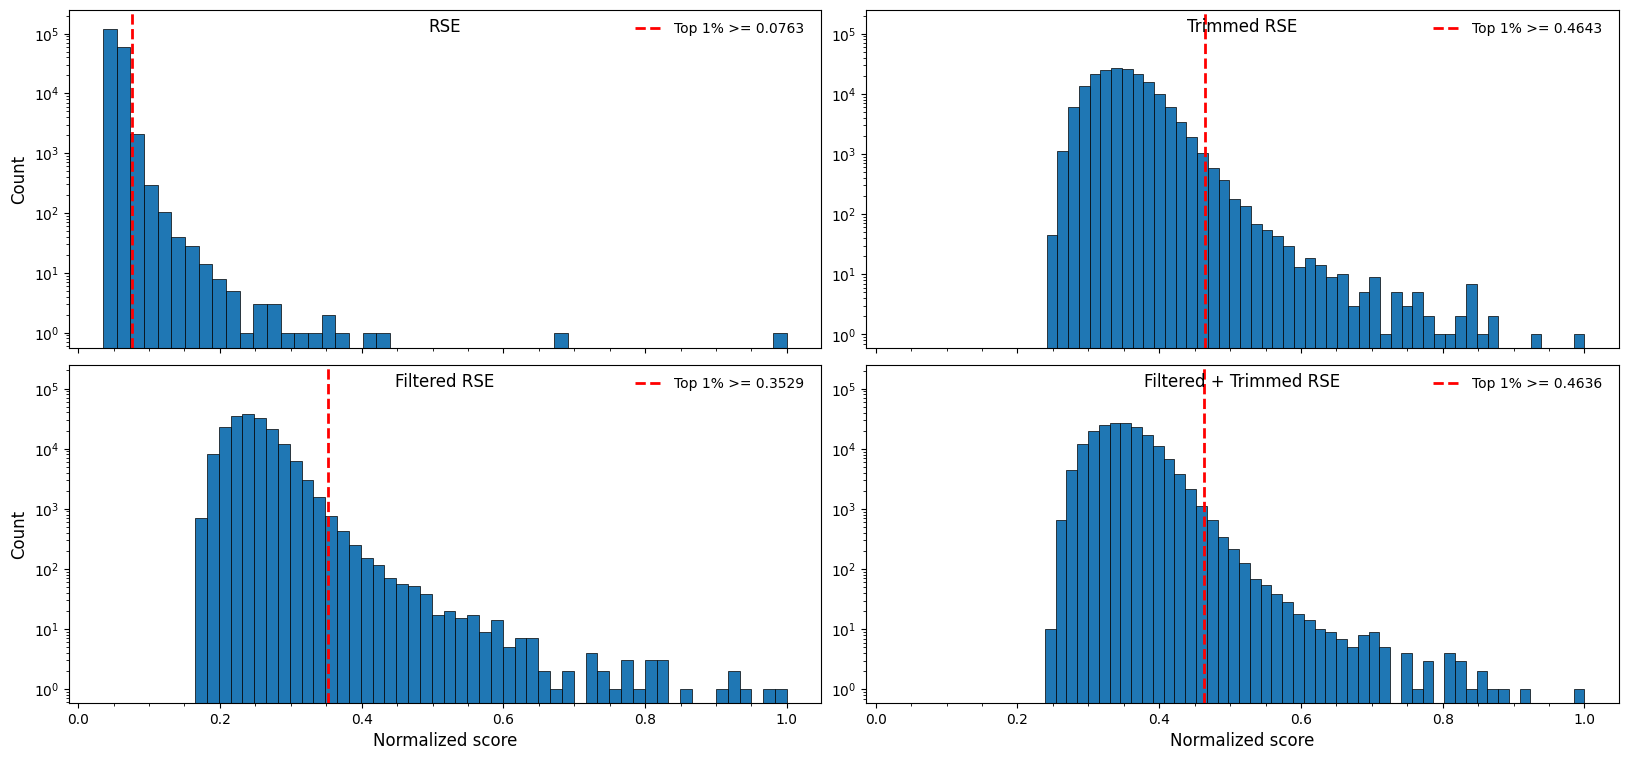

In [43]:
fig, axs = plot_hist_scores(
    merged_df,
    chi_sq_family,
    x_label='Normalized score',
    bins=50,
    y_lim=(None, 0.25e6)
)

for i, score in enumerate(chi_sq_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False)

axs[0].set_ylabel('Count', fontsize=12)
axs[2].set_ylabel('Count', fontsize=12)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hist_rse_scores_{bin_id}.pdf",
    bbox_inches='tight'
)

# Metadata histograms

## Redshift

In [44]:
z_quantile = 95
top_z_threshold = merged_df['z'].quantile(z_quantile/100)
print(f"z quantile: {z_quantile}%:")
print("-" * 40)
print(top_z_threshold)

z quantile: 95%:
----------------------------------------
0.188804915


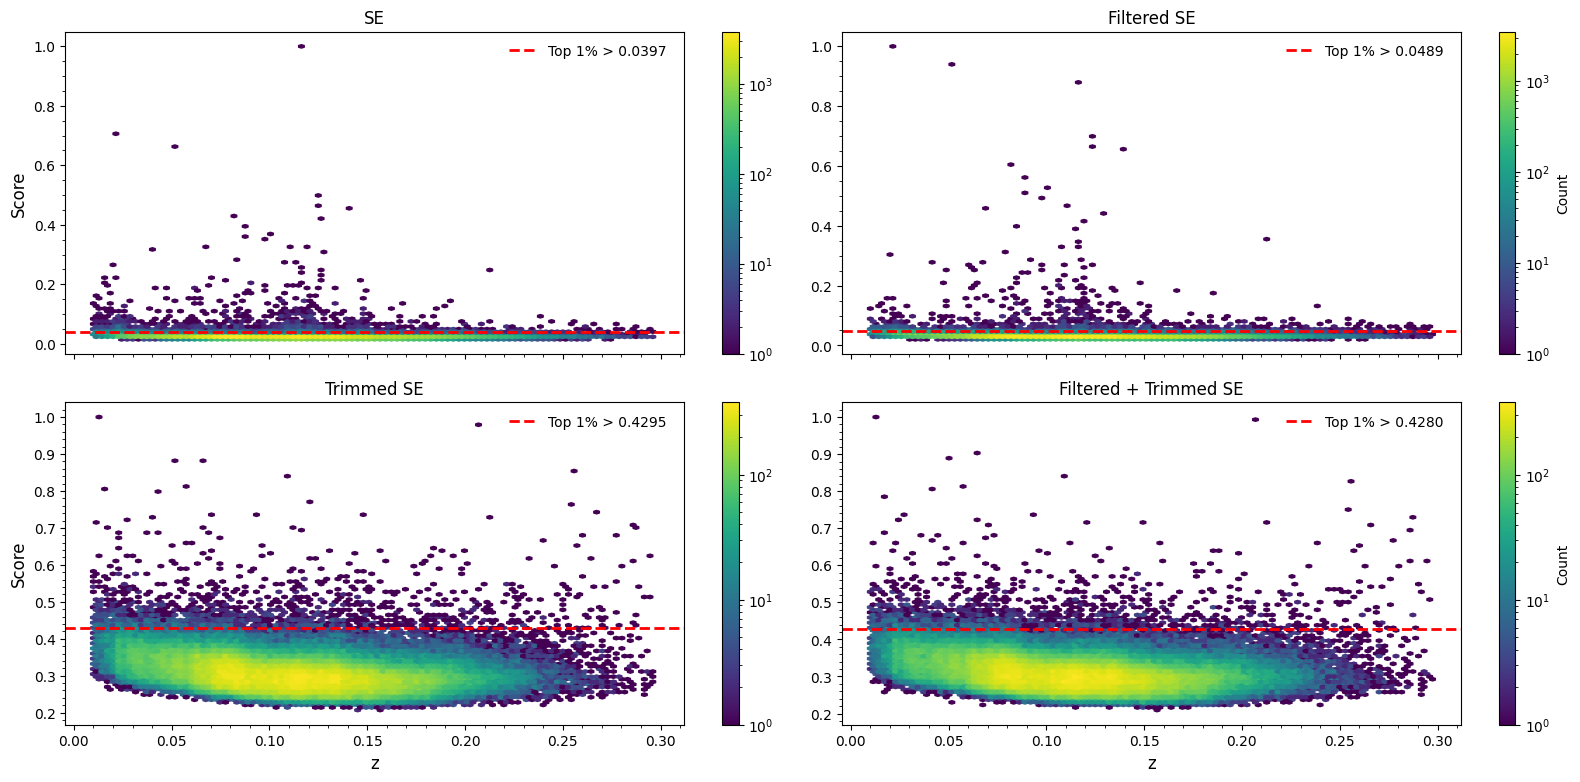

In [45]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_cols, 'z', 'z')

for i, score in enumerate(mse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% > {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_z_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'z {z_quantile}% quantile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hexbin_se_z_{bin_id}.pdf",
    bbox_inches='tight'
)

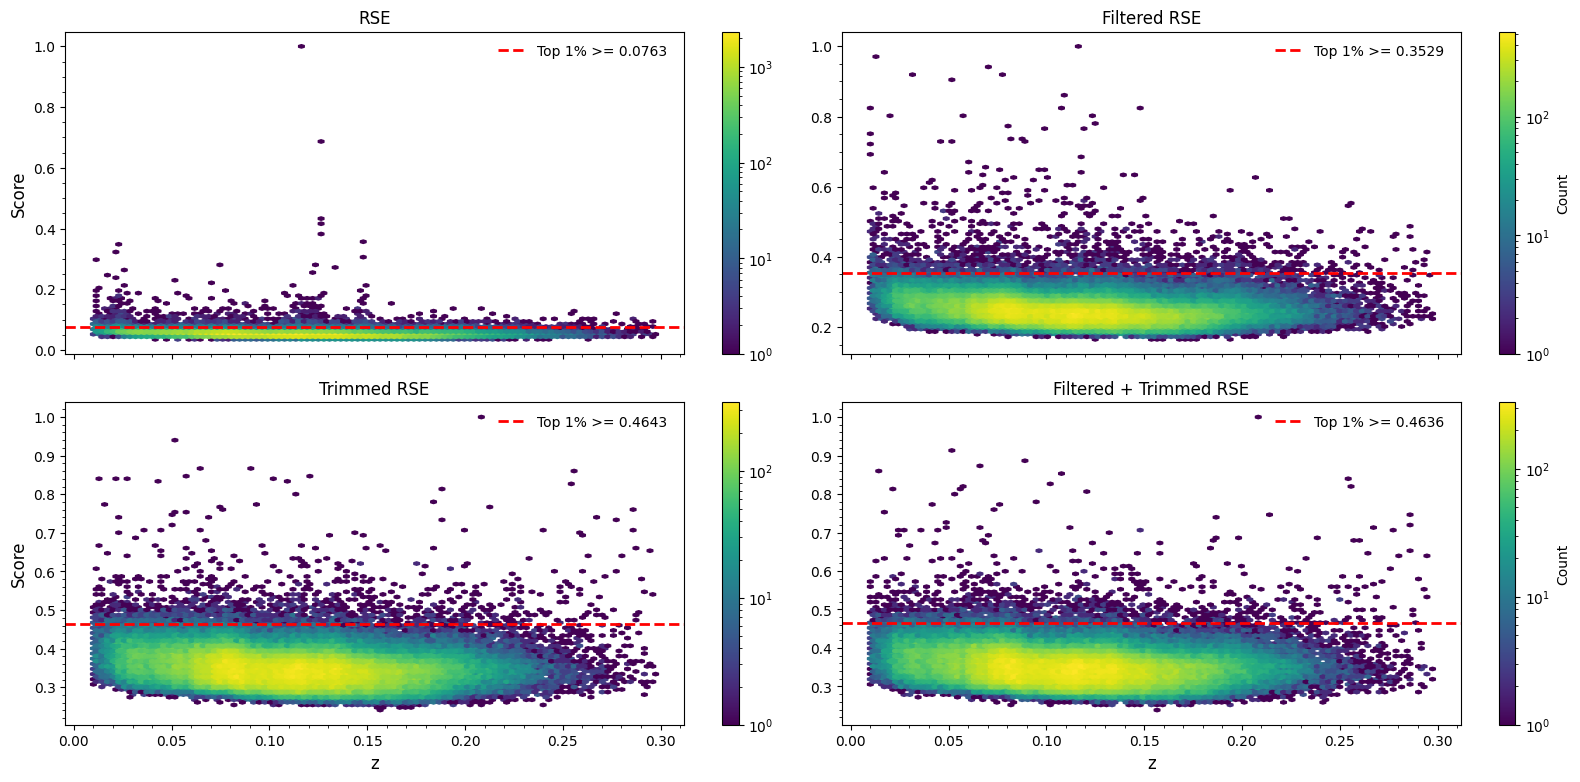

In [46]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_rel_cols, 'z', 'z')

for i, score in enumerate(mse_rel_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_z_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'z {z_quantile}% quantile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hexbin_rse_z_{bin_id}.pdf",
    bbox_inches='tight'
)

## S/N

In [47]:
snr_quantile = 95
top_snr_threshold = merged_df['snMedian'].quantile(snr_quantile/100)
print(f"z quantile: {snr_quantile}%:")
print("-" * 40)
print(top_snr_threshold)

z quantile: 95%:
----------------------------------------
17.2371475


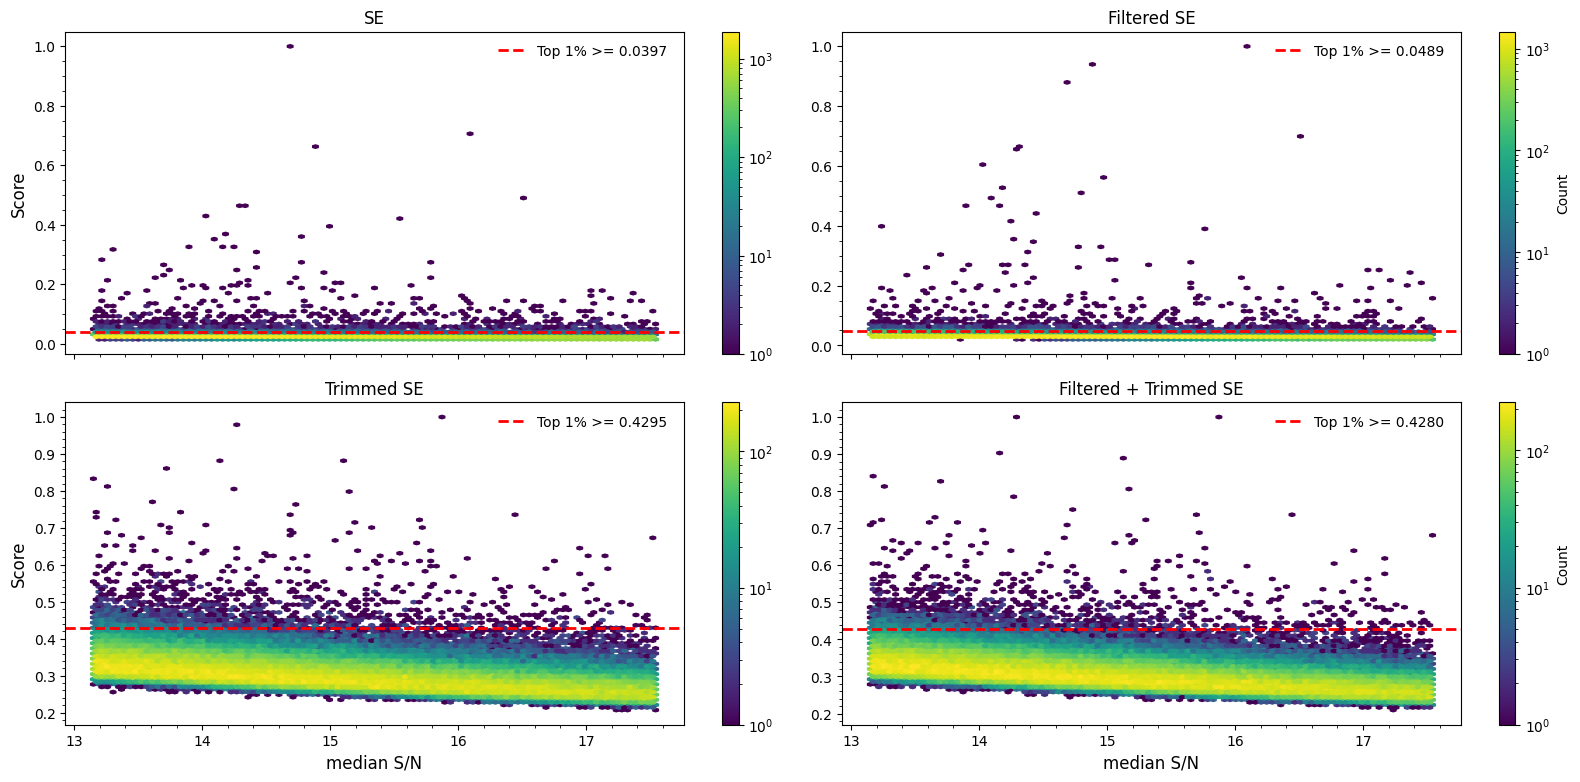

In [48]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_cols, 'snMedian', 'median S/N')

for i, score in enumerate(mse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_snr_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'median S/N {snr_quantile}% quantile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hexbin_se_snr_{bin_id}.pdf",
    bbox_inches='tight'
)

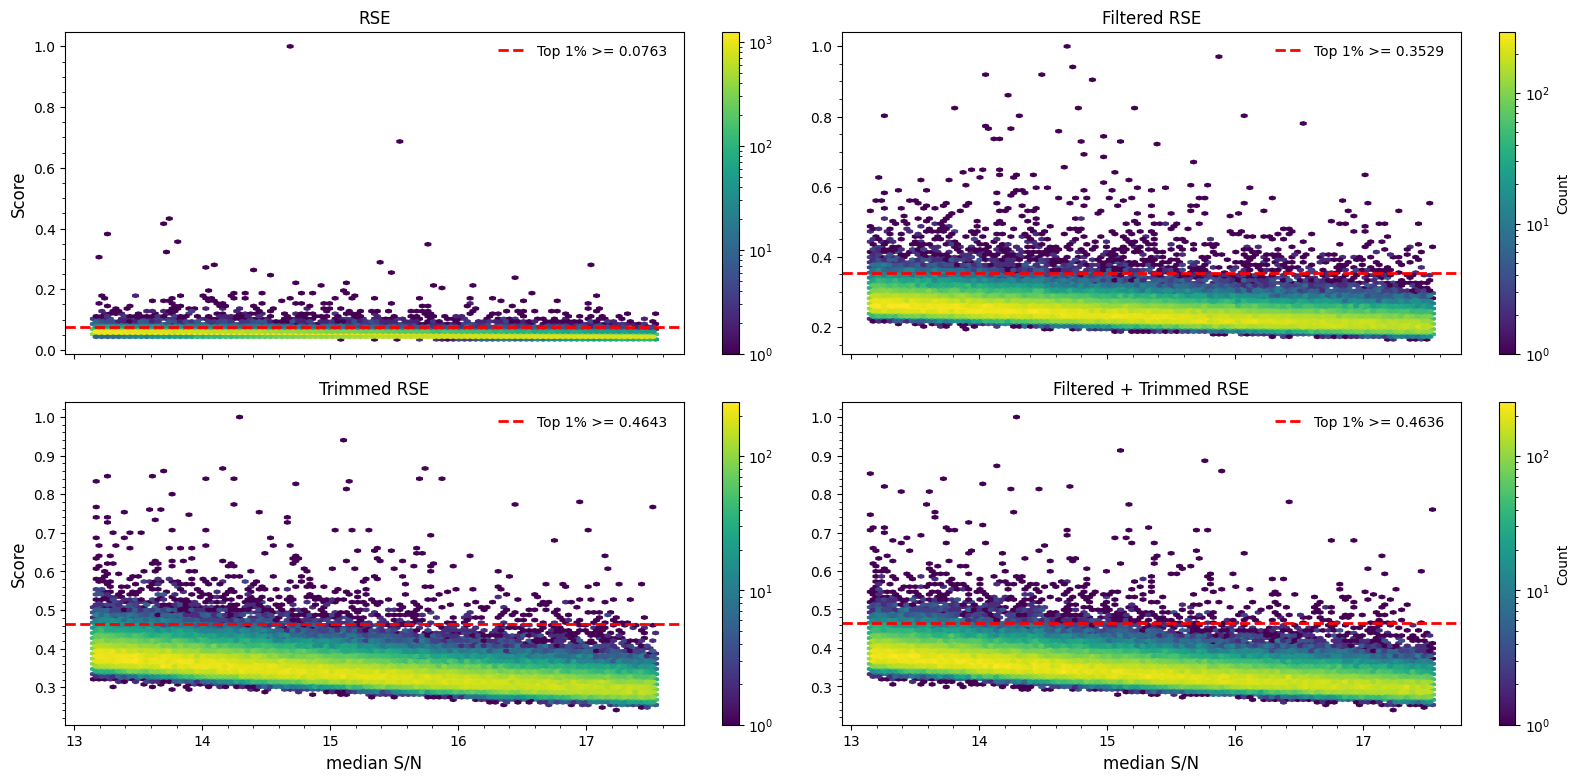

In [49]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_rel_cols, 'snMedian', 'median S/N')

for i, score in enumerate(mse_rel_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    
    # axs[i].axvline(
    #     x=top_snr_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'median S/N {snr_quantile}% quantile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/hexbin_rse_snr_{bin_id}.pdf",
    bbox_inches='tight'
)

# Median Specs

In [50]:
n_spec = merged_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

## MSE family

In [51]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_mse_top_1_dict = {}

for score in mse_cols:

    specids_top_1 = merged_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_mse_top_1_dict[score] = specids_top_1

In [52]:
spec_idx_mse_top_1_dict = {}

for score in mse_cols:
    
    spec_idx_list = []

    for objid in specids_mse_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_mse_top_1_dict[score] = spec_idx_list

### Spec prep

In [53]:
spec_mse = spectra[spec_idx_mse_top_1_dict['mse'], :]
spec_mse_median = np.nanmedian(spec_mse, axis=0)
spec_mse_mean = np.nanmean(spec_mse, axis=0)
# ------------------------------------------------------
spec_mse_filter = spectra[spec_idx_mse_top_1_dict['mse_filter_250'], :]
spec_mse_filter_median = np.nanmedian(spec_mse_filter, axis=0)
spec_mse_filter_mean = np.nanmean(spec_mse_filter, axis=0)
# ------------------------------------------------------
spec_trim = spectra[spec_idx_mse_top_1_dict['mse_97'], :]
spec_trim_median =  np.nanmedian(spec_trim, axis=0)
spec_trim_mean =  np.nanmean(spec_trim, axis=0)
# ------------------------------------------------------
spec_filter_trim = spectra[spec_idx_mse_top_1_dict['mse_filter_250_97'], :]
spec_filter_trim_median = np.nanmedian(spec_filter_trim, axis=0)
spec_filter_trim_mean = np.nanmean(spec_filter_trim, axis=0)


### Median spec

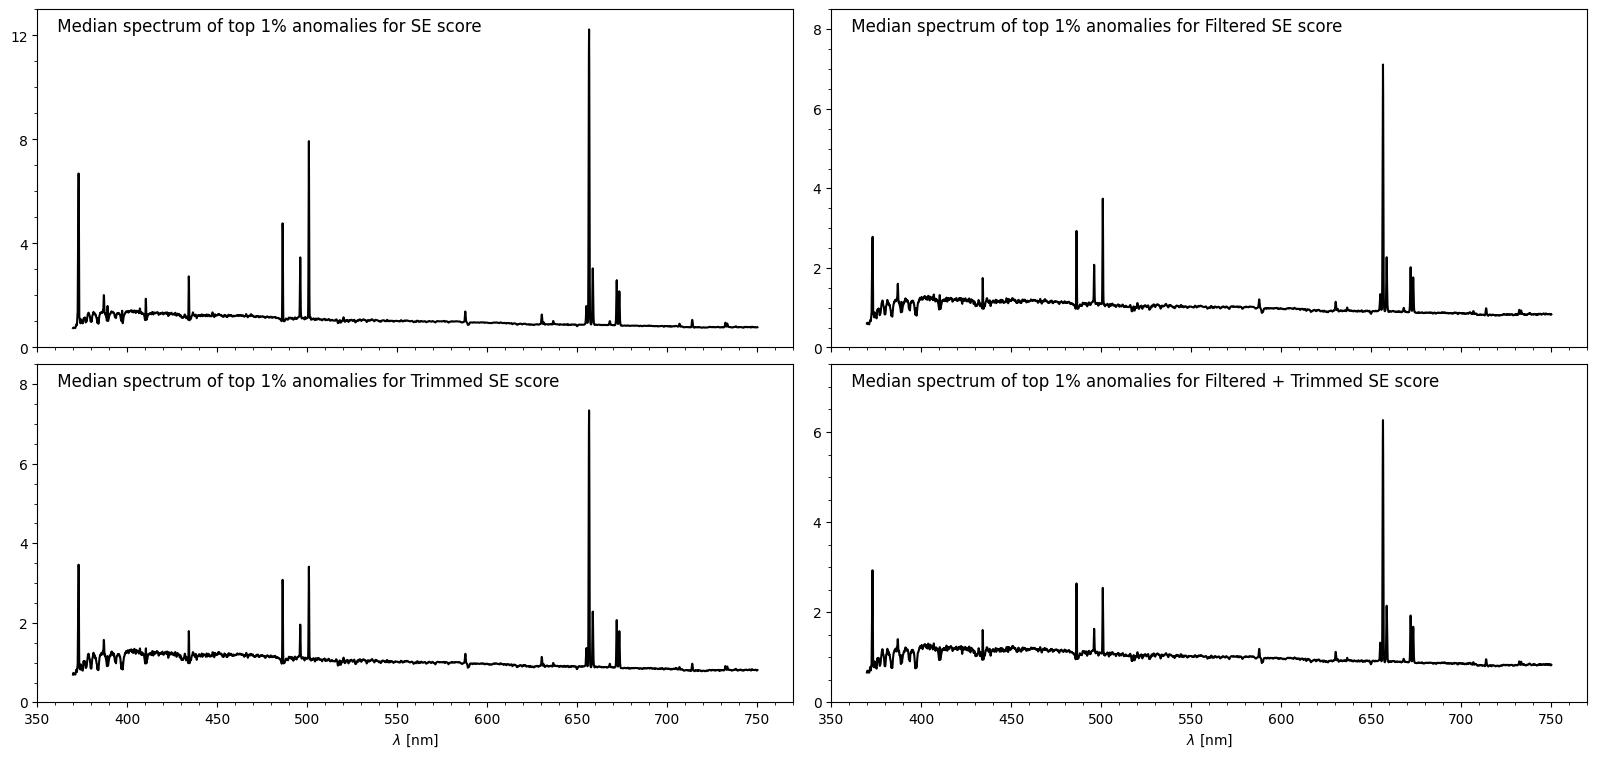

In [54]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_mse_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_mse_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_filter_trim_median, color='black')
# ------------------------------------------------------
# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["SE", "Filtered SE", "Trimmed SE", "Filtered + Trimmed SE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    if score == "SE":
        y_ticks = [0, 4, 8, 12]
        ax.set_ylim(0, 13)
    elif score == "Filtered SE":
        y_ticks = [0, 2, 4, 6, 8]
        ax.set_ylim(0, 8.5)
    elif score == "Trimmed SE":
        y_ticks = [0, 2, 4, 6, 8]
        ax.set_ylim(0, 8.5)
    else:  # Filtered + Trimmed RSE
        y_ticks = [0, 2, 4, 6]
        ax.set_ylim(0, 7.5)

    ax.set_yticks(y_ticks)

    ax.text(
        0.02, 0.95,
        f" Median spectrum of top 1% anomalies for {score} score",
        horizontalalignment="left", verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12
    )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/median_spec_top_se_{bin_id}.pdf",
    bbox_inches='tight'
)

### Mean spec

In [55]:
# fig, axs = plt.subplots(
#     2, 2,
#     sharex=True,
#     figsize=(20, 9)
# )

# # ------------------------------------------------------
# axs[0, 0].plot(wave_nm, spec_mse_mean, color='black')
# # ------------------------------------------------------
# axs[0, 1].plot(wave_nm, spec_mse_filter_mean, color='black')
# # ------------------------------------------------------
# axs[1, 0].plot(wave_nm, spec_trim_mean, color='black')
# # ------------------------------------------------------
# axs[1, 1].plot(wave_nm, spec_filter_trim_mean, color='black')

# # wavelengt setup
# axs[1, 0].set_xlim(350, 770)
# axs[1, 1].set_xlim(350, 770)
# # # wave_ticks = [370]
# wave_ticks = list(np.arange(350, 751, 50))
# axs[1, 0].set_xticks(wave_ticks)
# axs[1, 1].set_xticks(wave_ticks)


# scores_names = ["RSE", "Filtered RSE", "Trimmed RSE", "Filtered + Trimmed RSE"]

# for ax, score in zip(axs.flatten(), scores_names):
#     ax.minorticks_on()
#     y_ticks = [0, 5, 10, 15]
#     ax.set_yticks(y_ticks)
#     ax.set_ylim(0, 16)
#     ax.text(
#         0.02, 0.95,
#         f" Mean spectrum of top 1% anomalies for {score} score",
#         horizontalalignment="left", verticalalignment="center",
#         transform=ax.transAxes,
#         fontsize=12
#     )

# axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
# axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# # adjust vertical space
# plt.subplots_adjust(
#     hspace=0.05,
#     wspace=0.05
# )


## Chi sq family

In [56]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_chi_sq_top_1_dict = {}

for score in mse_rel_cols:

    specids_top_1 = merged_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_chi_sq_top_1_dict[score] = specids_top_1

In [57]:
spec_idx_chi_sq_top_1_dict = {}

for score in mse_rel_cols:
    
    spec_idx_list = []

    for objid in specids_chi_sq_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_chi_sq_top_1_dict[score] = spec_idx_list

### Spec prep

In [58]:
spec_chi = spectra[spec_idx_chi_sq_top_1_dict['mse_rel'], :]
spec_chi_median = np.nanmedian(spec_chi, axis=0)
spec_chi_mean = np.nanmean(spec_chi, axis=0)
# ------------------------------------------------------
spec_chi_filter = spectra[spec_idx_chi_sq_top_1_dict['mse_filter_250_rel'], :]
spec_chi_filter_median = np.nanmedian(spec_chi_filter, axis=0)
spec_chi_filter_mean = np.nanmean(spec_chi_filter, axis=0)
# ------------------------------------------------------
spec_chi_trim = spectra[spec_idx_chi_sq_top_1_dict['mse_97_rel'], :]
spec_chi_trim_median =  np.nanmedian(spec_chi_trim, axis=0)
spec_chi_trim_mean =  np.nanmean(spec_chi_trim, axis=0)
# ------------------------------------------------------
spec_chi_filter_trim = spectra[spec_idx_chi_sq_top_1_dict['mse_filter_250_97_rel'], :]
spec_chi_filter_trim_median = np.nanmedian(spec_chi_filter_trim, axis=0)
spec_chi_filter_trim_mean = np.nanmean(spec_chi_filter_trim, axis=0)

### Plot median spec

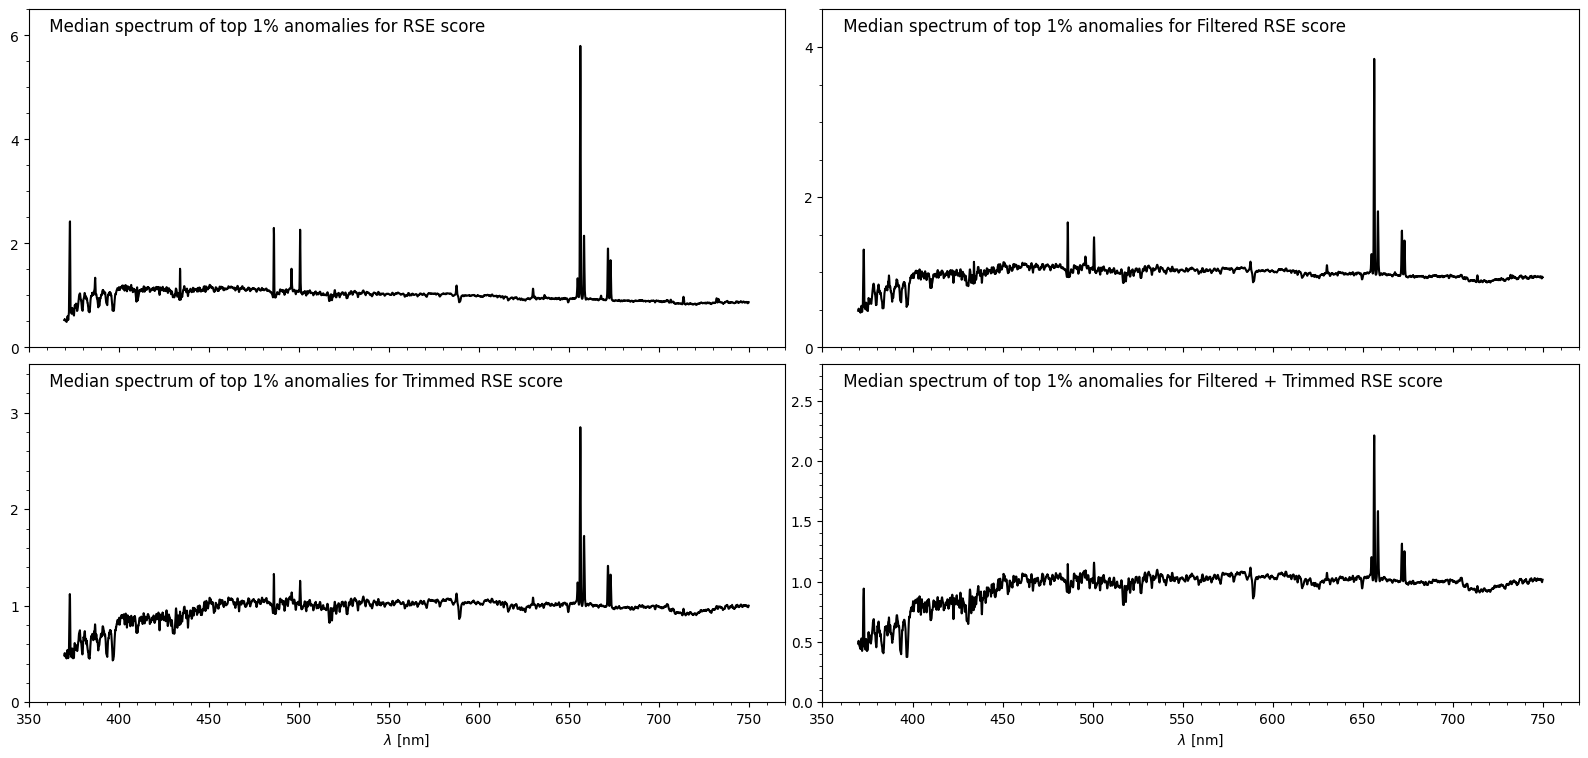

In [59]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_chi_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_chi_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_chi_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_chi_filter_trim_median, color='black')

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["RSE", "Filtered RSE", "Trimmed RSE", "Filtered + Trimmed RSE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    if score == "RSE":
        y_ticks = [0, 2, 4, 6]
        ax.set_ylim(0, 6.5)
    elif score == "Filtered RSE":
        y_ticks = [0, 2, 4]
        ax.set_ylim(0, 4.5)
    elif score == "Trimmed RSE":
        y_ticks = [0, 1, 2, 3]
        ax.set_ylim(0, 3.5)
    else:  # Filtered + Trimmed RSE
        y_ticks = [0, 0.5, 1, 1.5, 2.0, 2.5]
        ax.set_ylim(0, 2.8)

    ax.set_yticks(y_ticks)

    ax.text(
        0.02, 0.95,
        f" Median spectrum of top 1% anomalies for {score} score",
        horizontalalignment="left", verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12
    )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/median_spec_top_rse_{bin_id}.pdf",
    bbox_inches='tight'
)

### Plot mean

In [60]:
# fig, axs = plt.subplots(
#     2, 2,
#     sharex=True,
#     figsize=(20, 9)
# )

# # ------------------------------------------------------
# axs[0, 0].plot(wave_nm, spec_chi_mean, color='black')
# # ------------------------------------------------------
# axs[0, 1].plot(wave_nm, spec_chi_filter_mean, color='black')
# # ------------------------------------------------------
# axs[1, 0].plot(wave_nm, spec_chi_trim_mean, color='black')
# # ------------------------------------------------------
# axs[1, 1].plot(wave_nm, spec_chi_filter_trim_mean, color='black')

# plt.subplots_adjust(
#     hspace=0.05,
#     wspace=0.05
# )

# Scores overlap

In [61]:
(
    ids_a, ids_b,
    common_ids,
    only_in_a, only_in_b
) = AnomalyOverlapAnalyzer.overlap_pair_scores(
    score_a='mse',
    score_b='mse_filter_250',
    df=merged_df.copy(),
    quantile=99
)

overlap_pct = (len(common_ids)/len(ids_a))*100
f"{overlap_pct:.2f}%", len(ids_a), len(common_ids), len(only_in_a), len(only_in_b)

('66.68%', 1819, 1213, 606, 606)

In [62]:
all_scores = mse_cols + mse_rel_cols

overlap_df = pd.DataFrame(
    index=[map_score_name(s) for s in all_scores],
    columns=[map_score_name(s) for s in all_scores],
    dtype=float
)

for score_a in all_scores:

    for score_b in all_scores:

        if score_a == score_b:

            overlap_df.loc[map_score_name(score_a), map_score_name(score_b)] = 100.0

        else:
            ids_a, ids_b, common, _, _ = AnomalyOverlapAnalyzer.overlap_pair_scores(
                score_a, score_b, merged_df
            )

            pct = (len(common) / len(ids_a)) * 100
            overlap_df.loc[map_score_name(score_a), map_score_name(score_b)] = pct

overlap_df.round(2)

,SE,Filtered SE,Trimmed SE,Filtered + Trimmed SE,RSE,Filtered RSE,Trimmed RSE,Filtered + Trimmed RSE
SE,100.00,66.68,41.07,34.69,57.56,42.94,26.83,22.10
Filtered SE,66.68,100.00,50.69,47.06,63.55,61.63,38.32,34.47
Trimmed SE,41.07,50.69,100.00,87.30,48.43,48.21,61.57,55.74
Filtered + Trimmed SE,34.69,47.06,87.30,100.00,46.40,47.88,63.88,59.70
RSE,57.56,63.55,48.43,46.40,100.00,79.66,48.82,44.75
Filtered RSE,42.94,61.63,48.21,47.88,79.66,100.00,53.99,51.68
Trimmed RSE,26.83,38.32,61.57,63.88,48.82,53.99,100.00,85.93
Filtered + Trimmed RSE,22.10,34.47,55.74,59.70,44.75,51.68,85.93,100.00


## SE family

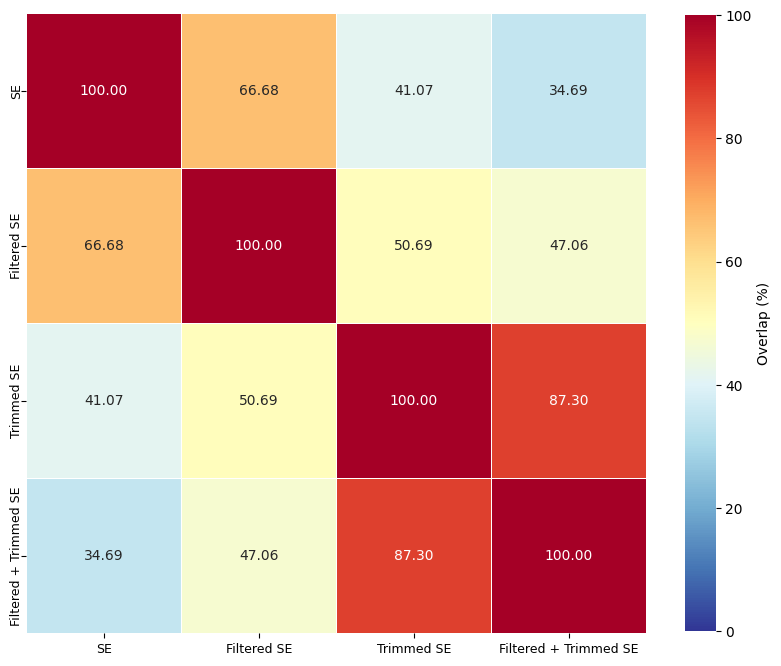

In [83]:
fig = plt.figure(figsize=(10, 10))

mapped_se_cols = [map_score_name(s) for s in mse_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_se_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)
# plt.title("Percentage Overlap of Top 1% Anomalies", fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/heatmap_overlap_se_scores_{bin_id}.pdf",
    bbox_inches='tight'
)

## RSE family

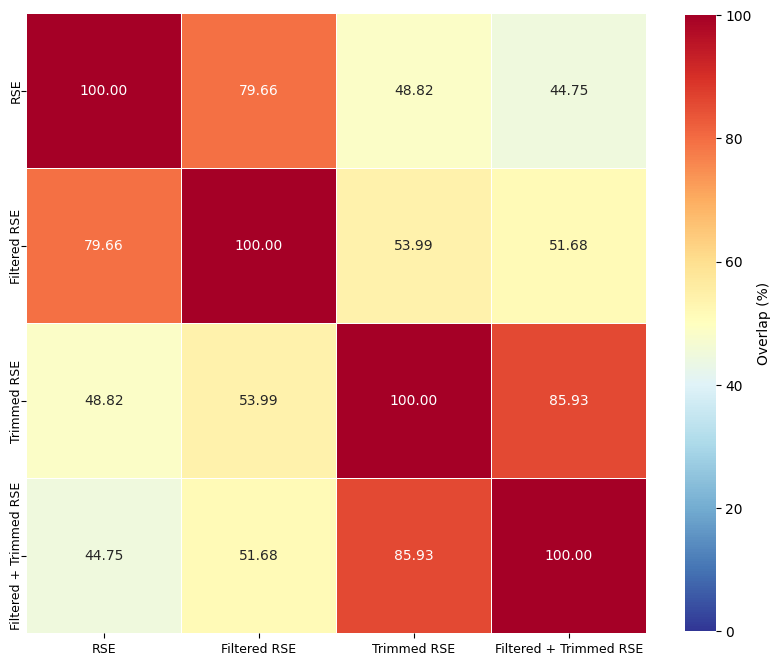

In [84]:
fig = plt.figure(figsize=(10, 10))

mapped_rse_cols = [map_score_name(s) for s in mse_rel_cols]

sns.heatmap(
    overlap_df.loc[mapped_rse_cols, mapped_rse_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)
# plt.title("Percentage Overlap of Top 1% Anomalies", fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/heatmap_overlap_rse_scores_{bin_id}.pdf",
    bbox_inches='tight'
)

## SE Vs RSE

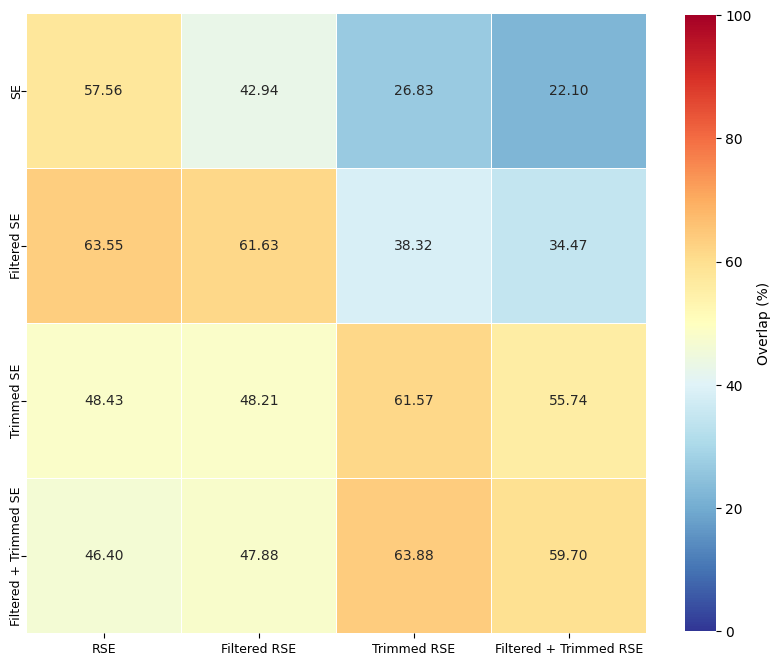

In [85]:
fig = plt.figure(figsize=(10, 10))
mapped_se_cols = [map_score_name(s) for s in mse_cols]
mapped_rse_cols = [map_score_name(s) for s in mse_rel_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_rse_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)
# plt.title("Percentage Overlap of Top 1% Anomalies", fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)

# save figure
save_to = f"{ch_4_dir}/{bin_id}"
os.makedirs(save_to, exist_ok=True)

fig.savefig(
    f"{save_to}/heatmap_overlap_all_scores_{bin_id}.pdf",
    bbox_inches='tight'
)